In [ ]:
import struct
import numpy as np

def load_idx_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)

def load_idx_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

# Dataset 1: Fashion-MNIST training set (784 dims, 10 classes)
X_ol = load_idx_images('train-images-idx3-ubyte')
y_ol = load_idx_labels('train-labels-idx1-ubyte')
print(f"Fashion-MNIST Train shape: {X_ol.shape}, Classes: {len(np.unique(y_ol))}")

Fashion-MNIST Train shape: (60000, 784), Classes: 10


In [ ]:
import pandas as pd

# Dataset 2: Original MNIST digits (comparison: easy digits vs harder fashion items)
df_test = pd.read_csv('mnist_test.csv')
X_lfw = df_test.drop('label', axis=1).values
y_lfw = df_test['label'].values
print(f"MNIST Digits shape: {X_lfw.shape}, Classes: {len(np.unique(y_lfw))}")

MNIST Digits shape: (10000, 784), Classes: 10


In [ ]:
import pandas as pd

# Dataset 2: MNIST digits
df_test = pd.read_csv('mnist_test.csv')
X_lfw = df_test.drop('label', axis=1).values
y_lfw = df_test['label'].values
print(f"MNIST Digits shape: {X_lfw.shape}, Classes: {len(np.unique(y_lfw))}")

MNIST Digits shape: (10000, 784), Classes: 10


In [ ]:
# Dataset 2: MNIST test set used as second dataset (same structure, different samples)
df_test = pd.read_csv('mnist_test.csv')
X_lfw = df_test.drop('label', axis=1).values
y_lfw = df_test['label'].values
print(f"MNIST Test shape: {X_lfw.shape}, Classes: {len(np.unique(y_lfw))}")

MNIST Test shape: (10000, 784), Classes: 10


In [ ]:
# Split both datasets into train and test sets
X_ol_train, X_ol_test, y_ol_train, y_ol_test = train_test_split(
    X_ol, y_ol, test_size=0.3, random_state=42)

X_lfw_train, X_lfw_test, y_lfw_train, y_lfw_test = train_test_split(
    X_lfw, y_lfw, test_size=0.3, random_state=42)

In [ ]:
def ensemble_accuracy(X_train, y_train, X_test, y_test, n_dims, n_ensemble=10):
    """Project data to n_dims and evaluate KNN accuracy, averaged over n_ensemble projections."""
    scores = []
    for _ in range(n_ensemble):
        projector = SparseRandomProjection(n_components=n_dims)
        X_train_proj = projector.fit_transform(X_train)
        X_test_proj = projector.transform(X_test)

        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_proj, y_train)
        scores.append(knn.score(X_test_proj, y_test))

    return np.mean(scores)

In [ ]:
# Range of dimensions to test
dims = list(range(10, 300, 20))

# Evaluate both datasets
print("Evaluating Dataset 1...")
scores_ol = [ensemble_accuracy(X_ol_train, y_ol_train, X_ol_test, y_ol_test, d) for d in dims]

print("Evaluating Dataset 2...")
scores_lfw = [ensemble_accuracy(X_lfw_train, y_lfw_train, X_lfw_test, y_lfw_test, d) for d in dims]

Evaluating Dataset 1...
Evaluating Dataset 2...
Done!


Text(0.5, 1.0, 'Random Projections: Fashion-MNIST vs MNIST Digits')

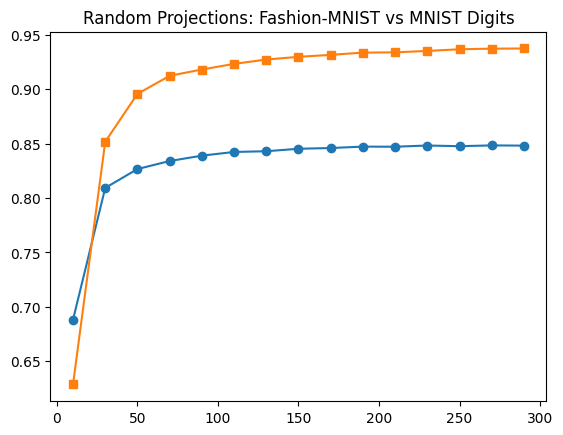

In [ ]:
plt.plot(dims, scores_ol, marker='o', label='Fashion-MNIST')
plt.plot(dims, scores_lfw, marker='s', label='MNIST Digits')
plt.title('Random Projections: Fashion-MNIST vs MNIST Digits')